Our expectation with the original LEMBAS is as follows:
1) It cannot handle multiple cell types
2) It cannot account for the dispersion within a cluster at single-cell resolution, and will output the centroid of a cluster instead.

Next, we want to see whether scLEMBAS can capture the heterogeneity of cell responses upon ligand exposure. 

In [1]:
import os
from itertools import combinations

import numpy as np
import pandas as pd

import anndata
import scanpy as sc
from sklearn.neighbors import NearestCentroid
from scipy.spatial.distance import cdist, pdist, squareform

import torch

import matplotlib.pyplot as plt
import seaborn as sns
import plotnine as p9
import patchworklib as pw

import sys

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import parse_network, io
from scLEMBAS.model.scl import SignalingModel
from scLEMBAS.model.train import TrainCat
from scLEMBAS.plotting import plot_embedding
from scLEMBAS.preprocess import embed_tf_activity

<Figure size 100x100 with 0 Axes>

In [2]:
n_cores = 12
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888

device = "cuda" if torch.cuda.is_available() else "cpu"

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
models_path = os.path.join(data_path, 'processed', 'models')
if not os.path.isdir(models_path):
    os.mkdir(models_path)

In [3]:
tf_adata = io.read_tfad(file_name = os.path.join(data_path, 'processed', 'ID_tf_activity.h5ad'))

# Load and Parse Input Signaling Network

In [4]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

In [5]:
sn_ppis = parse_network.load_network('omnipath', organism = 'mouse', static = True)
sn_ppis = parse_network.extract_network(sn_ppis, curation_effort_thresh = 5, n_references_thresh = 3,
                                        resources = ['HuRI','IntAct','KEGG-MEDICUS','NetPath','Reactome_SignaLink3','SPIKE','SignaLink3','SIGNOR', 
                                                'Baccin2019', 'Ramilowski2015', 'Reactome_LRdb', 'UniProt_LRdb', 'CellChatDB', 'CellPhoneDB', 'connectomeDB2020', 'scConnect'], 
                                        drop_self = True, verbose = True)

The thresholds filtered 21403  of 28277 interactions
The resources filtered 937  of 6874 interactions


Filter for nodes that fall in paths between ligands and receptors (fully connected network):

In [6]:
tf_labels = tf_adata.var.index.unique().tolist()

ligand_labels = tf_adata.obs['sample'].unique().tolist()
ligand_labels = [(l[0] + l[1:].lower()).replace('-', '') for l in ligand_labels] # mouse naming convention

# filter for paths b/w ligand and tf
fn_1 = parse_network.fully_connected_network(sn_ppis, ligand_labels, tf_labels, source_label = source_label, target_label = target_label, 
                       path_finder = 'shortest')
fn_2 = parse_network.fully_connected_network(sn_ppis, ligand_labels, tf_labels, source_label = source_label, target_label = target_label, 
                       path_finder = 'connected')
# of the methods to identify paths, retain the one that has the most interactions
if fn_1.shape[0] > fn_2.shape[0]:
    sn_ppis = fn_1
else:
    sn_ppis = fn_2

del fn_1, fn_2

100%|████████████████████████████████████| 8122/8122 [00:00<00:00, 17508.31it/s]


Finally, let's format the network as needed for input to building the model:

In [7]:
# for the interactions that are labeled as both stimulating and inhibiting, relabel them as unknown (can only have one direction)
sn_ppis.loc[sn_ppis[(sn_ppis[stimulation_label] == 1) & (sn_ppis[inhibition_label] == 1)].index, 
    [stimulation_label, inhibition_label]] = [False, False]
sn_ppis = parse_network.format_network(sn_ppis, weight_label, stimulation_label, inhibition_label) 

In [8]:
print('The signaling network contains {} interactions'.format(sn_ppis.shape[0]))
sn_ppis[[source_label, target_label, weight_label, stimulation_label, inhibition_label]].head()

The signaling network contains 619 interactions


,source_genesymbol,target_genesymbol,mode_of_action,consensus_stimulation,consensus_inhibition
0,Mapk14,Mapkapk2,1.0,True,False
1,Mapkapk2,Mapk14,0.1,False,False
2,Akt1,Chuk,1.0,True,False
3,Tp53,Atf3,1.0,True,False
4,Abl1,Tp73,1.0,True,False


The interactions include the following input ligands:

In [9]:
all_nodes = sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()
input_ligands_available = sorted(set(ligand_labels).intersection(all_nodes))
print(*input_ligands_available, sep = ', ')

Egf, Gdnf, Hgf, Ifng, Il10, Il11, Il13, Il15, Il1a, Il1b, Il2, Il21, Il4, Il5, Il6, Il7, Il9, Lif, Osm, Tslp


# Explore performance on TF activity

In [10]:
group_label = 'TF_clusters' # ordered cateogry in obs

## Scenario 2:

In [11]:
model_no = 2

The simplest scenario is:
- 2 cell type
- 1 ligand
- Binary ligand exposure (0 or 1)
- Exposure leads to distinct clusters in TF activity space

For now, we simply use visualization to identify the most distinct clusters:

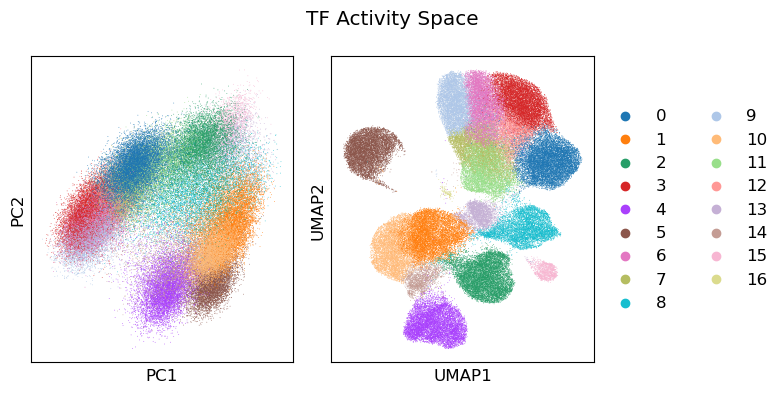

In [12]:
fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))
sc.pl.pca(tf_adata, color='TF_clusters', ax = ax[0], show = False)
ax[0].legend().set_visible(False)
ax[0].set_title('')
sc.pl.umap(tf_adata, color='TF_clusters', ax = ax[1], show = False)
ax[1].set_title('')

fig.suptitle('TF Activity Space')

fig.tight_layout()
# plt.savefig(fname = os.path.join(data_path, 'figures', 'tf_celltype_umap.png'), 
#             transparent = True, 
#             bbox_inches = 'tight')
plt.show()

Based on these results, we choose clusters 2, 3, 4, and 5:

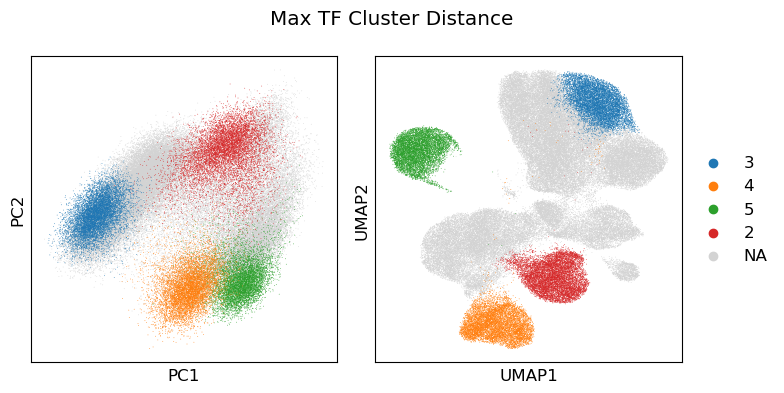

In [13]:
max_clusters = ['3', '4', '5', '2']
viz_adata = tf_adata.copy()
viz_adata.obs[group_label + '_color'] = pd.Categorical(viz_adata.obs[group_label], 
                                                       categories = max_clusters, 
                                                       ordered = True)
fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))
sc.pl.pca(viz_adata, color=group_label + '_color', ax = ax[0], show = False)
ax[0].legend().set_visible(False)
ax[0].set_title('')
sc.pl.umap(viz_adata, color=group_label + '_color', ax = ax[1], show = False)
ax[1].set_title('')

fig.suptitle('Max TF Cluster Distance')

fig.tight_layout()
# plt.savefig(fname = os.path.join(data_path, 'figures', 'tf_celltype_umap.png'), 
#             transparent = True, 
#             bbox_inches = 'tight')
plt.show()

Based on these results, let's say that cluster 9 is unstimulated, and cluster 15 is stimulated. 

In [14]:
np.random.seed(seed)
selected_ligand = np.random.choice(input_ligands_available, 1)[0]
print('The selected ligand is: ' + selected_ligand)

subset_tf = tf_adata[tf_adata.obs.TF_clusters.isin(max_clusters)]
subset_tf.obs.TF_clusters.value_counts()

The selected ligand is: Il5


TF_clusters
2    8483
3    8155
4    7704
5    7318
Name: count, dtype: int64

For now, for speed, let's subset so that there are a smaller number of "samples" per condition:

In [15]:
sample_size = int(2.5e3)

barcodes = []
for cluster_label in subset_tf.obs.TF_clusters.unique():
    bc = subset_tf.obs[subset_tf.obs.TF_clusters == cluster_label].index
    np.random.seed(seed)
    barcodes += list(np.random.choice(bc, sample_size, replace = False))
subset_tf = subset_tf[barcodes, :]
subset_tf.obs.TF_clusters.value_counts()

TF_clusters
2    2500
3    2500
4    2500
5    2500
Name: count, dtype: int64

Next, let's initialize the model. 

Let's say clusters 4 and 5 are unstimulated, and 3 and 2 are stimulated
We assign clusters 3 and 4 as cell Type A, and 5 and 2 as cell type B.

In [16]:
ligand_input = pd.DataFrame(subset_tf.obs.TF_clusters.map({'4': 0, '5': 0, '3': 1, '2': 1}))
ligand_input.columns = [selected_ligand]


covariates = pd.DataFrame(subset_tf.obs.TF_clusters.map({'3': 'A', '4': 'A',
                                                        '5': 'B', '2': 'B'}))
covariates.columns = ['celltype']


tf_output = pd.DataFrame(subset_tf.X, index = subset_tf.obs.index, columns = subset_tf.var.index)

In [17]:
subset_tf.obs = pd.concat([covariates, ligand_input, pd.DataFrame({'TF_clusters': subset_tf.obs.TF_clusters})], axis = 1)

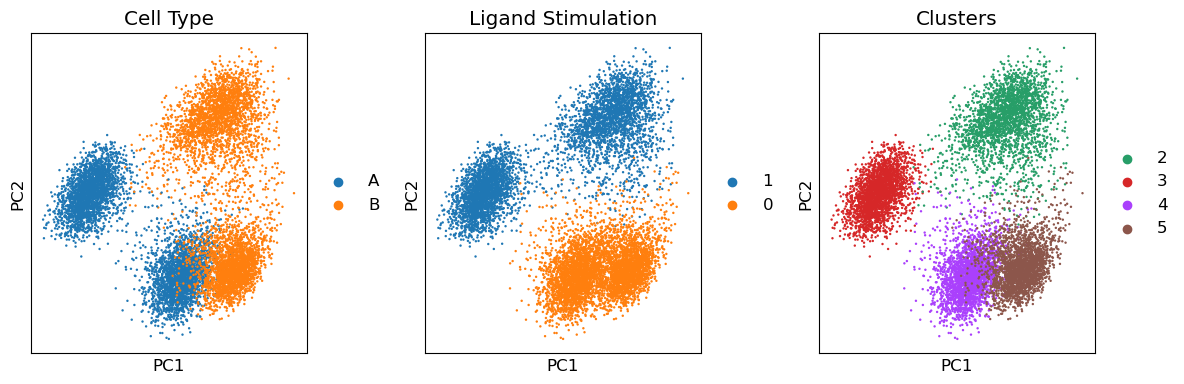

In [18]:
viz_adata = subset_tf.copy()
for col in viz_adata.obs.columns:
    viz_adata.obs[col] = pd.Categorical(viz_adata.obs[col],
                                        categories = viz_adata.obs[col].unique())


fig, ax = plt.subplots(ncols = 3, figsize = (12, 4))
sc.pl.pca(viz_adata, color='celltype', ax = ax[0], show = False)
ax[0].set_title('Cell Type')

sc.pl.pca(viz_adata, color=selected_ligand, ax = ax[1], show = False)
ax[1].set_title('Ligand Stimulation')

sc.pl.pca(viz_adata, color='TF_clusters', ax = ax[2], show = False)
ax[2].set_title('Clusters')


fig.tight_layout()
plt.show()

In [19]:
# linear scaling of inputs/outputs
projection_amplitude_in = 3
projection_amplitude_out = 1.2
# other parameters
bionet_params = {'target_steps': 100, 
                 'max_steps': 120, 
                 'exp_factor':50, 
                 'tolerance': 1e-5, 
                 'leak':1e-2, 
                'cat_max_norm': 1} 

# training parameters
lr_params = {'max_epochs': int(1e4), 
             'learning_rate': 2e-3, 
             'reset_optimizer_epoch': 200}

other_params = {'batch_size': 256, 
                'network_noise_scale': 10, 
                'gradient_noise_scale': 1e-9}

regularization_params = {'param_lambda_L2': 1e-6, 
                         'discriminator_lambda_L2': 1e-5,
                         'moa_lambda_L1': 0.1, #'ligand_lambda_L2': 1e-5, 
                         'uniform_lambda_L2': 1e-4,  
                         'uniform_max': (1/1.2), 
                         'spectral_loss_factor': 1e-5}

spectral_radius_params = {'n_probes_spectral': 5, 
                          'power_steps_spectral': 50, 
                          'subset_n_spectral': 10}
training_params = {**lr_params, **other_params, **regularization_params, **spectral_radius_params}
target_spectral_radius = 0.8

In [20]:
mod = SignalingModel(net = sn_ppis,
                     X_in = ligand_input,
                     y_out = tf_output, 
                     covariates = subset_tf.obs,
                     categorical_covariate_keys = ['celltype'],
                     projection_amplitude_in = projection_amplitude_in, projection_amplitude_out = projection_amplitude_out,
                     weight_label = weight_label, source_label = source_label, target_label = target_label,
                     bionet_params = bionet_params, 
                     dtype = torch.float32, device = device, seed = seed)

Next, let's train the model:

In [ ]:
# model setup
mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

# training loop
trainer = TrainCat(mod = mod,
                   prediction_optimizer = torch.optim.Adam,
                   prediction_loss_fn = torch.nn.MSELoss(reduction='mean'),
                   hyper_params = training_params,
                   train_split_frac = {'train': 0.8, 'test': 0.2, 'validation': None}, 
                   train_seed = seed)
mod, cur_loss, cur_eig, split_data_dict, stats = trainer.train_model(verbose = True)

# store results
io.write_pickled_object(stats, os.path.join(models_path, 'model_' + str(model_no) + '_training_stats.pickle'))
torch.save(obj=mod.state_dict(), f=os.path.join(models_path, 'model_' + str(model_no) + '_state_dict.pth'))

for df_type, df in split_data_dict.items():
    if df is not None:
        df.to_csv(os.path.join(models_path, 'model_' + str(model_no) + '_' + df_type + '.csv'))

  0%|                                      | 1/10000 [00:04<11:57:20,  4.30s/it]

i=0, l=1.16595, s=0.849, r=0.00020, v=0


  1%|▎                                    | 101/10000 [05:50<8:57:22,  3.26s/it]

i=100, l=0.79239, s=0.531, r=0.00024, v=0


  2%|▋                                    | 201/10000 [12:34<9:51:47,  3.62s/it]

...

 15%|████▉                            | 1501/10000 [1:47:36<11:21:18,  4.81s/it]

i=1500, l=0.39482, s=0.505, r=0.00198, v=1


 16%|█████▎                           | 1601/10000 [1:55:52<12:46:50,  5.48s/it]

i=1600, l=0.39569, s=0.539, r=0.00198, v=1


 17%|█████▌                           | 1676/10000 [2:01:56<11:03:05,  4.78s/it]

In [ ]:
mod.load_state_dict(torch.load(os.path.join(models_path, 'model_' + str(model_no) + '_state_dict.pth')))#, 
                              #map_location=torch.device('cpu')))
stats = io.read_pickled_object(os.path.join(models_path, 'model_' + str(model_no) + '_training_stats.pickle'))

split_data_dict = dict()
for df_type in ['X_test', 'X_train', 'X_val', 'y_test', 'y_train', 'y_val']:
    fn = os.path.join(models_path, 'model_' + str(model_no) + '_' + df_type + '.csv')
    if os.path.isfile(fn):
        split_data_dict[df_type] = pd.read_csv(fn, index_col = 0)
X_test = split_data_dict['X_test']
y_train = split_data_dict['y_train']

In [ ]:
io.write_pickled_object([], 'complete_run.pickle')

# You are here

Let's see what the output looks like:

In [ ]:
def unique_tol(arr, tol=1e-5, axis=0):
    if axis == 1:
        arr = arr.T
    norm_arr = arr / arr[:, [0]]
    
    # Sort the array based on rows
    sorted_indices = np.lexsort(norm_arr.T)
    sorted_arr = arr[sorted_indices, :]
    
    # Calculate the differences between consecutive rows
    diffs = np.diff(sorted_arr, axis=0)
    
    # Use a norm (e.g., L2 norm) to find row differences, then check against tolerance
    row_diffs = np.linalg.norm(diffs, axis=1)
    unique_row_indices = np.where(row_diffs > tol)[0]
    
    # Add the first row and the rows after significant changes
    unique_indices = np.r_[0, unique_row_indices + 1]
    
    # Select the unique rows
    unique_rows = sorted_arr[unique_indices, :]
    
    if axis == 1:
        unique_rows = unique_rows.T
        
    return unique_rows

We expect 4 unique predictions, one for each ligand/cell type combination:

In [ ]:
covariates_idx = mod.signaling_network.covariates_to_tensor(sample_ids = X_test.index)
X_test_tensor = mod.df_to_tensor(X_test)
y_pred, Y_full = mod(X_test_tensor, covariates_idx)
y_pred = y_pred.cpu().detach().numpy()

y_pred_unique = unique_tol(y_pred, tol = 1e-5, axis = 0)
print('The number of unique predictions across all test data is {}'.format(len(y_pred_unique)))

We can see that there are only 2 unique prediction values, because the model is currently not aware of single-cell resolution (or cell type) data. Let's see what exactly these predicted values are:

In [ ]:
ligand_input[selected_ligand] = pd.Categorical(ligand_input[selected_ligand], 
                                              categories = sorted(ligand_input[selected_ligand].unique()), 
                                              ordered = True)

# get the centroids in the full TF activity space
clf_full = NearestCentroid()
train_cats = subset_tf.obs.loc[y_train.index, ['celltype', selected_ligand]]
train_cats = train_cats.celltype.str.cat(train_cats[selected_ligand].astype(str), sep='_')
clf_full.fit(y_train, train_cats)
train_centroids = pd.DataFrame(clf_full.centroids_ , index = clf_full.classes_, columns = y_train.columns)

# get the predictions for stimulated (1) and unstimulated (0) b/w cell types A and B
test_preds = pd.DataFrame(index = train_centroids.index, columns = train_centroids.columns)
for ct in subset_tf.obs.celltype.unique():
    for ls in subset_tf.obs[selected_ligand].unique():
        cat_idx = subset_tf.obs[(subset_tf.obs.celltype == ct) & (subset_tf.obs[selected_ligand] == ls)].index
        cat_idx = cat_idx[cat_idx.isin(X_test.index)]
        # sample_id = cat_idx[0]
        covariates_idx = mod.signaling_network.covariates_to_tensor(cat_idx)
        X_test_ = mod.df_to_tensor(X_test.loc[cat_idx, :])
        y_pred, Y_full = mod(X_test_, covariates_idx)
        y_pred = unique_tol(y_pred.cpu().detach().numpy(), tol = 1e-5, axis = 0)
        
        test_preds.loc[ct + '_' + str(ls), :] = y_pred

# re-run the PCA on the training subset to visualize/project into this space
tf_adata_train = tf_adata[y_train.index, y_train.columns].copy()
tf_adata_train.obs.drop(columns = ['TF_clusters'], inplace = True)
tf_adata_train = embed_tf_activity(tf_adata_train, estimate_key = None, scanpy_pca = False)
tf_adata_train.TF_clusters = tf_adata[y_train.index, y_train.columns].obs.TF_clusters # replace with original clusters
pca = tf_adata_train.uns['pca']['pca_mod']

# get the train dataset centroids as well as project the predictions into pca space 
train_pca_centroids = pca.transform(train_centroids)
pred_pca_centroids = pca.transform(test_preds.values)

In [ ]:
viz_adata_ = viz_adata.copy()
viz_adata_ = viz_adata_[tf_adata_train.obs.index, ]
viz_adata_.obs['Condition'] = viz_adata_.obs.celltype.str.cat(viz_adata_.obs[selected_ligand].astype(str), sep='_')
train_cats = viz_adata_.obs.copy()

In [ ]:
w, h = 5,4
p1 = plot_embedding(adata = viz_adata_, group_label = 'Condition', embedding = 'pca', 
                    palette = 'Set2', width = w, height = h, size = 0.5)
p1 + p9.theme(figure_size=(w, h))

In [ ]:
# train_pc_rank = tf_adata_train.uns['pca']['pca_rank']
# y_train_eds_full = list()
# y_train_eds_reduced = list()
# for idx in y_train.index:
#     # full TF space
#     y_vals = y_train.loc[idx, :]
#     pred_type = train_cats.loc[idx, 'Condition']
#     y_centroid = train_centroids.loc[pred_type, :]

#     ed = np.linalg.norm(y_vals - y_centroid)
#     y_train_eds_full.append(ed)

#     # reduced space
#     y_vals = tf_adata_train.obsm['X_pca'][tf_adata_train.obs.index.tolist().index(idx),:][:train_pc_rank]
#     y_centroid = train_pca_centroids[train_centroids.index.tolist().index(pred_type), :][:train_pc_rank]

#     ed = np.linalg.norm(y_vals - y_centroid)
#     y_train_eds_reduced.append(ed)   
    
# fig, ax = plt.subplots(figsize = (12,3), ncols = 2)

# colors = sns.color_palette('Set1')

# sns.kdeplot(y_train_eds_full, ax = ax[0], color = colors[0])
# # children = plt.gca().get_children()
# l0 = ax[0].vlines(np.linalg.norm(y_pred_0 - train_centroids.loc[0,:].values), ymin = 0, ymax = 0.95*ax[0].get_ylim()[1], color = colors[1])
# l1 = ax[0].vlines(np.linalg.norm(y_pred_1 - train_centroids.loc[1,:].values), ymin = 0, ymax = 0.95*ax[0].get_ylim()[1], color = colors[2])
# ax[0].set_xlabel('Euclidean Distance to Training Centroid')
# ax[0].set_title('Full TF Activity Space')

# sns.kdeplot(y_train_eds_reduced, ax = ax[1], color = colors[0])
# children = plt.gca().get_children()
# l0 = ax[1].vlines(np.linalg.norm(pred_pca_centroids[0,:train_pc_rank] - train_pca_centroids[0,:train_pc_rank]), ymin = 0, ymax = 0.95*ax[1].get_ylim()[1], color = colors[1])
# l1 = ax[1].vlines(np.linalg.norm(pred_pca_centroids[1,:train_pc_rank] - train_pca_centroids[1,:train_pc_rank]), ymin = 0, ymax = 0.95*ax[1].get_ylim()[1], color = colors[2])
# ax[1].set_xlabel('Euclidean Distance to Training Centroid')
# ax[1].set_title('Reduced TF Activity Space ({} PCs)'.format(train_pc_rank))

# plt.legend([children[0], l0, l1], ['Training Data', 'Prediction: Unstimulated', 'Prediction: Stimulated'], 
#           bbox_to_anchor=(1, 1.05))
# fig.tight_layout()

In [ ]:
tf_adata_train.obs['Condition'] = viz_adata_.obs['Condition']

# training data
X_train = tf_adata_train.obsm['X_pca']
X_train = pd.DataFrame(tf_adata_train.obsm['X_pca'][:, :2], index = tf_adata_train.obs.index, 
                         columns = ['PC_' + str(i+1) for i in range(2)])
col_labels = [' '.join(i.split('_')) for i in X_train.columns]
X_train = pd.concat([X_train, tf_adata_train.obs.Condition], axis = 1)

In [ ]:
width, height = 5, 3
set1_colors = ['#E41A1C', '#377EB8', '#4DAF4A', '#984EA3', '#FF7F00', '#FFFF33', '#A65628']



tf_adata_train.obs['Condition'] = viz_adata_.obs['Condition']

# training data
X_train = tf_adata_train.obsm['X_pca']
X_train = pd.DataFrame(tf_adata_train.obsm['X_pca'][:, :2], index = tf_adata_train.obs.index, 
                         columns = ['PC_' + str(i+1) for i in range(2)])
col_labels = [' '.join(i.split('_')) for i in X_train.columns]
X_train = pd.concat([X_train, tf_adata_train.obs.Condition], axis = 1)

# centroids and predicted values
X_centroids = pd.DataFrame(train_pca_centroids[:, :2], index = clf_full.classes_, 
                     columns = ['PC_' + str(i+1) for i in range(2)])
X_pred = pd.DataFrame(pred_pca_centroids[:, :2], index = clf_full.classes_, 
                     columns = ['PC_' + str(i+1) for i in range(2)])

p3 = (
    p9.ggplot() +
    p9.geom_point(X_train, p9.aes(x=X_train.columns[0], y = X_train.columns[1], color = 'Condition'), 
                 size = 0.1) +
    p9.scale_color_manual(values=set1_colors) +
    p9.geom_point(X_centroids, p9.aes(x=X_centroids.columns[0], y = X_centroids.columns[1]), shape = 'X', color = 'black') +
    p9.geom_point(X_pred, p9.aes(x=X_pred.columns[0], y = X_pred.columns[1]), shape = '*', color = 'blue') +
    p9.xlab(col_labels[0]) + p9.ylab(col_labels[1]) + 
    p9.theme_bw() + p9.theme(figure_size=(width, height))  
    
)
p3